# 🌾 Seasonal Agricultural Performance & Yield Optimization Analysis
**VOIS AICTE Internship Major Project (Batch 1, 2026–2027)**

---

## 📌 Project Information
* **Student Name**: Prathamesh Thorwat
* **AICTE Student ID**: STU6a07fdf0488dd1778908656
* **College Name**: MET BKC Institute of Engineering, Nashik
* **GitHub Repository**: https://github.com/mrsonu-boop/seasonal_agriculture_performance_analysis

---

## 🎯 Enhanced Analytical Objectives
1. **In-Depth Data Auditing**: Evaluate missingness, distribution skewness, standard deviation spreads, and outlier patterns across all 28 variables[cite: 1].
2. **Nutrient & Soil Chemistry Analysis**: Analyze the influence of Soil pH, Soil Moisture, and NPK balances on crop yields[cite: 1].
3. **Multi-Panel Visualization**: Produce statistical charts covering violin plots, box plots, correlation matrices, state-wise heatmaps, and regression scatter plots[cite: 1].

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set high-resolution visual styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 300

# File Path Configuration
FILE_NAME = 'seasonal_agriculture_performance_dataset.csv'

if os.path.exists(FILE_NAME):
    df = pd.read_csv(FILE_NAME)
    print("=" * 80)
    print(f" SUCCESS: Dataset loaded successfully from '{FILE_NAME}'")
    print(f" Dataset Shape: {df.shape[0]:,} Rows | {df.shape[1]} Columns")
    print("=" * 80)
else:
    raise FileNotFoundError(f"❌ File '{FILE_NAME}' not found. Please upload it to Colab.")

 SUCCESS: Dataset loaded successfully from 'seasonal_agriculture_performance_dataset.csv'
 Dataset Shape: 4,000 Rows | 28 Columns


In [20]:
print("=" * 80)
print("1. DATASET SCHEMA & DATA TYPES")
print("=" * 80)
df.info()

print("\n" + "=" * 80)
print("2. MISSING DATA AUDIT")
print("=" * 80)
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': null_counts, 'Percentage (%)': null_pct})
display(missing_df[missing_df['Missing Values'] > 0])

print("\n" + "=" * 80)
print("3. EXTENDED NUMERICAL STATISTICAL SUMMARY (SKEWNESS & IQR)")
print("=" * 80)
num_cols = df.select_dtypes(include=[np.number]).columns
stats_df = df[num_cols].describe().T
stats_df['Skewness'] = df[num_cols].skew()
stats_df['IQR'] = stats_df['75%'] - stats_df['25%']
display(stats_df[['count', 'mean', 'std', 'min', '50%', 'max', 'Skewness', 'IQR']].style.format('{:.2f}'))

print("\n" + "=" * 80)
print("4. CATEGORICAL FEATURE DISTRIBUTION AUDIT")
print("=" * 80)
cat_cols = ['State', 'Season', 'Crop', 'Irrigation_Method']
for col in cat_cols:
    print(f"\n--- Distribution for {col} ---")
    print(df[col].value_counts())

1. DATASET SCHEMA & DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha   

,Missing Values,Percentage (%)
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8



3. EXTENDED NUMERICAL STATISTICAL SUMMARY (SKEWNESS & IQR)


,count,mean,std,min,50%,max,Skewness,IQR
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,7.89,15.00,-0.04,7.39
Rainfall_mm,3952.00,601.15,288.93,80.00,582.00,1395.20,0.14,464.75
Avg_Temperature_C,4000.00,26.82,3.82,16.20,26.90,39.70,0.00,5.70
Humidity_pct,4000.00,63.21,11.96,25.00,63.00,95.00,-0.02,17.13
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,7.30,11.00,0.07,1.50
Soil_pH,4000.00,6.70,0.64,5.20,6.69,8.40,0.05,0.88
Soil_Moisture_pct,3960.00,26.51,6.71,8.00,26.40,47.00,-0.03,9.60
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,120.10,220.00,0.02,42.72
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,57.50,120.00,0.08,23.20
Potassium_kg_ha,4000.00,104.76,27.74,30.00,105.10,200.00,-0.05,37.40



4. CATEGORICAL FEATURE DISTRIBUTION AUDIT

--- Distribution for State ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- Distribution for Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Distribution for Crop ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Distribution for Irrigation_Method ---
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [21]:
df_clean = df.copy()

# 1. Group-wise Median Imputation by Season
df_clean['Rainfall_mm'] = df_clean['Rainfall_mm'].fillna(
    df_clean.groupby('Season')['Rainfall_mm'].transform('median')
)
df_clean['Soil_Moisture_pct'] = df_clean['Soil_Moisture_pct'].fillna(
    df_clean.groupby('Season')['Soil_Moisture_pct'].transform('median')
)

# Impute Yield using Production / Farm Area
mask_missing_yield = df_clean['Yield_Tonnes_Ha'].isnull()
df_clean.loc[mask_missing_yield, 'Yield_Tonnes_Ha'] = (
    df_clean.loc[mask_missing_yield, 'Production_Tonnes'] / df_clean.loc[mask_missing_yield, 'Farm_Area_Hectares']
)

# 2. Advanced Engineered Domain Features
df_clean['NPK_Total_kg_ha'] = df_clean['Nitrogen_kg_ha'] + df_clean['Phosphorus_kg_ha'] + df_clean['Potassium_kg_ha']
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR']) * 100
df_clean['Cost_per_Hectare'] = df_clean['Total_Cost_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Revenue_per_Hectare'] = df_clean['Revenue_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Is_Profitable'] = df_clean['Profit_INR'] > 0

# 3. Categorical Risk Binning
df_clean['Risk_Level'] = pd.cut(
    df_clean['Disease_Pest_Risk_pct'],
    bins=[0, 35, 60, 100],
    labels=['Low Risk', 'Moderate Risk', 'High Risk']
)

print("=" * 80)
print("✅ PREPROCESSING & FEATURE ENGINEERING COMPLETE")
print(f" Remaining Null Values: {df_clean.isnull().sum().sum()}")
print(" Added Features: NPK_Total_kg_ha, Profit_Margin_pct, Cost_per_Hectare, Revenue_per_Hectare, Is_Profitable, Risk_Level")
print("=" * 80)

✅ PREPROCESSING & FEATURE ENGINEERING COMPLETE
 Remaining Null Values: 0
 Added Features: NPK_Total_kg_ha, Profit_Margin_pct, Cost_per_Hectare, Revenue_per_Hectare, Is_Profitable, Risk_Level


/tmp/ipykernel_859/765631434.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Production_Tonnes', ax=axes[0, 0], ci=None, palette='viridis', edgecolor='black')
/tmp/ipykernel_859/765631434.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Production_Tonnes', ax=axes[0, 0], ci=None, palette='viridis', edgecolor='black')
/tmp/ipykernel_859/765631434.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', ax=axes[0, 1], palette='Set2', inner='quartile')
/tmp/ipykernel_859/765631434.py:14: FutureWarning: 

Passing `palette

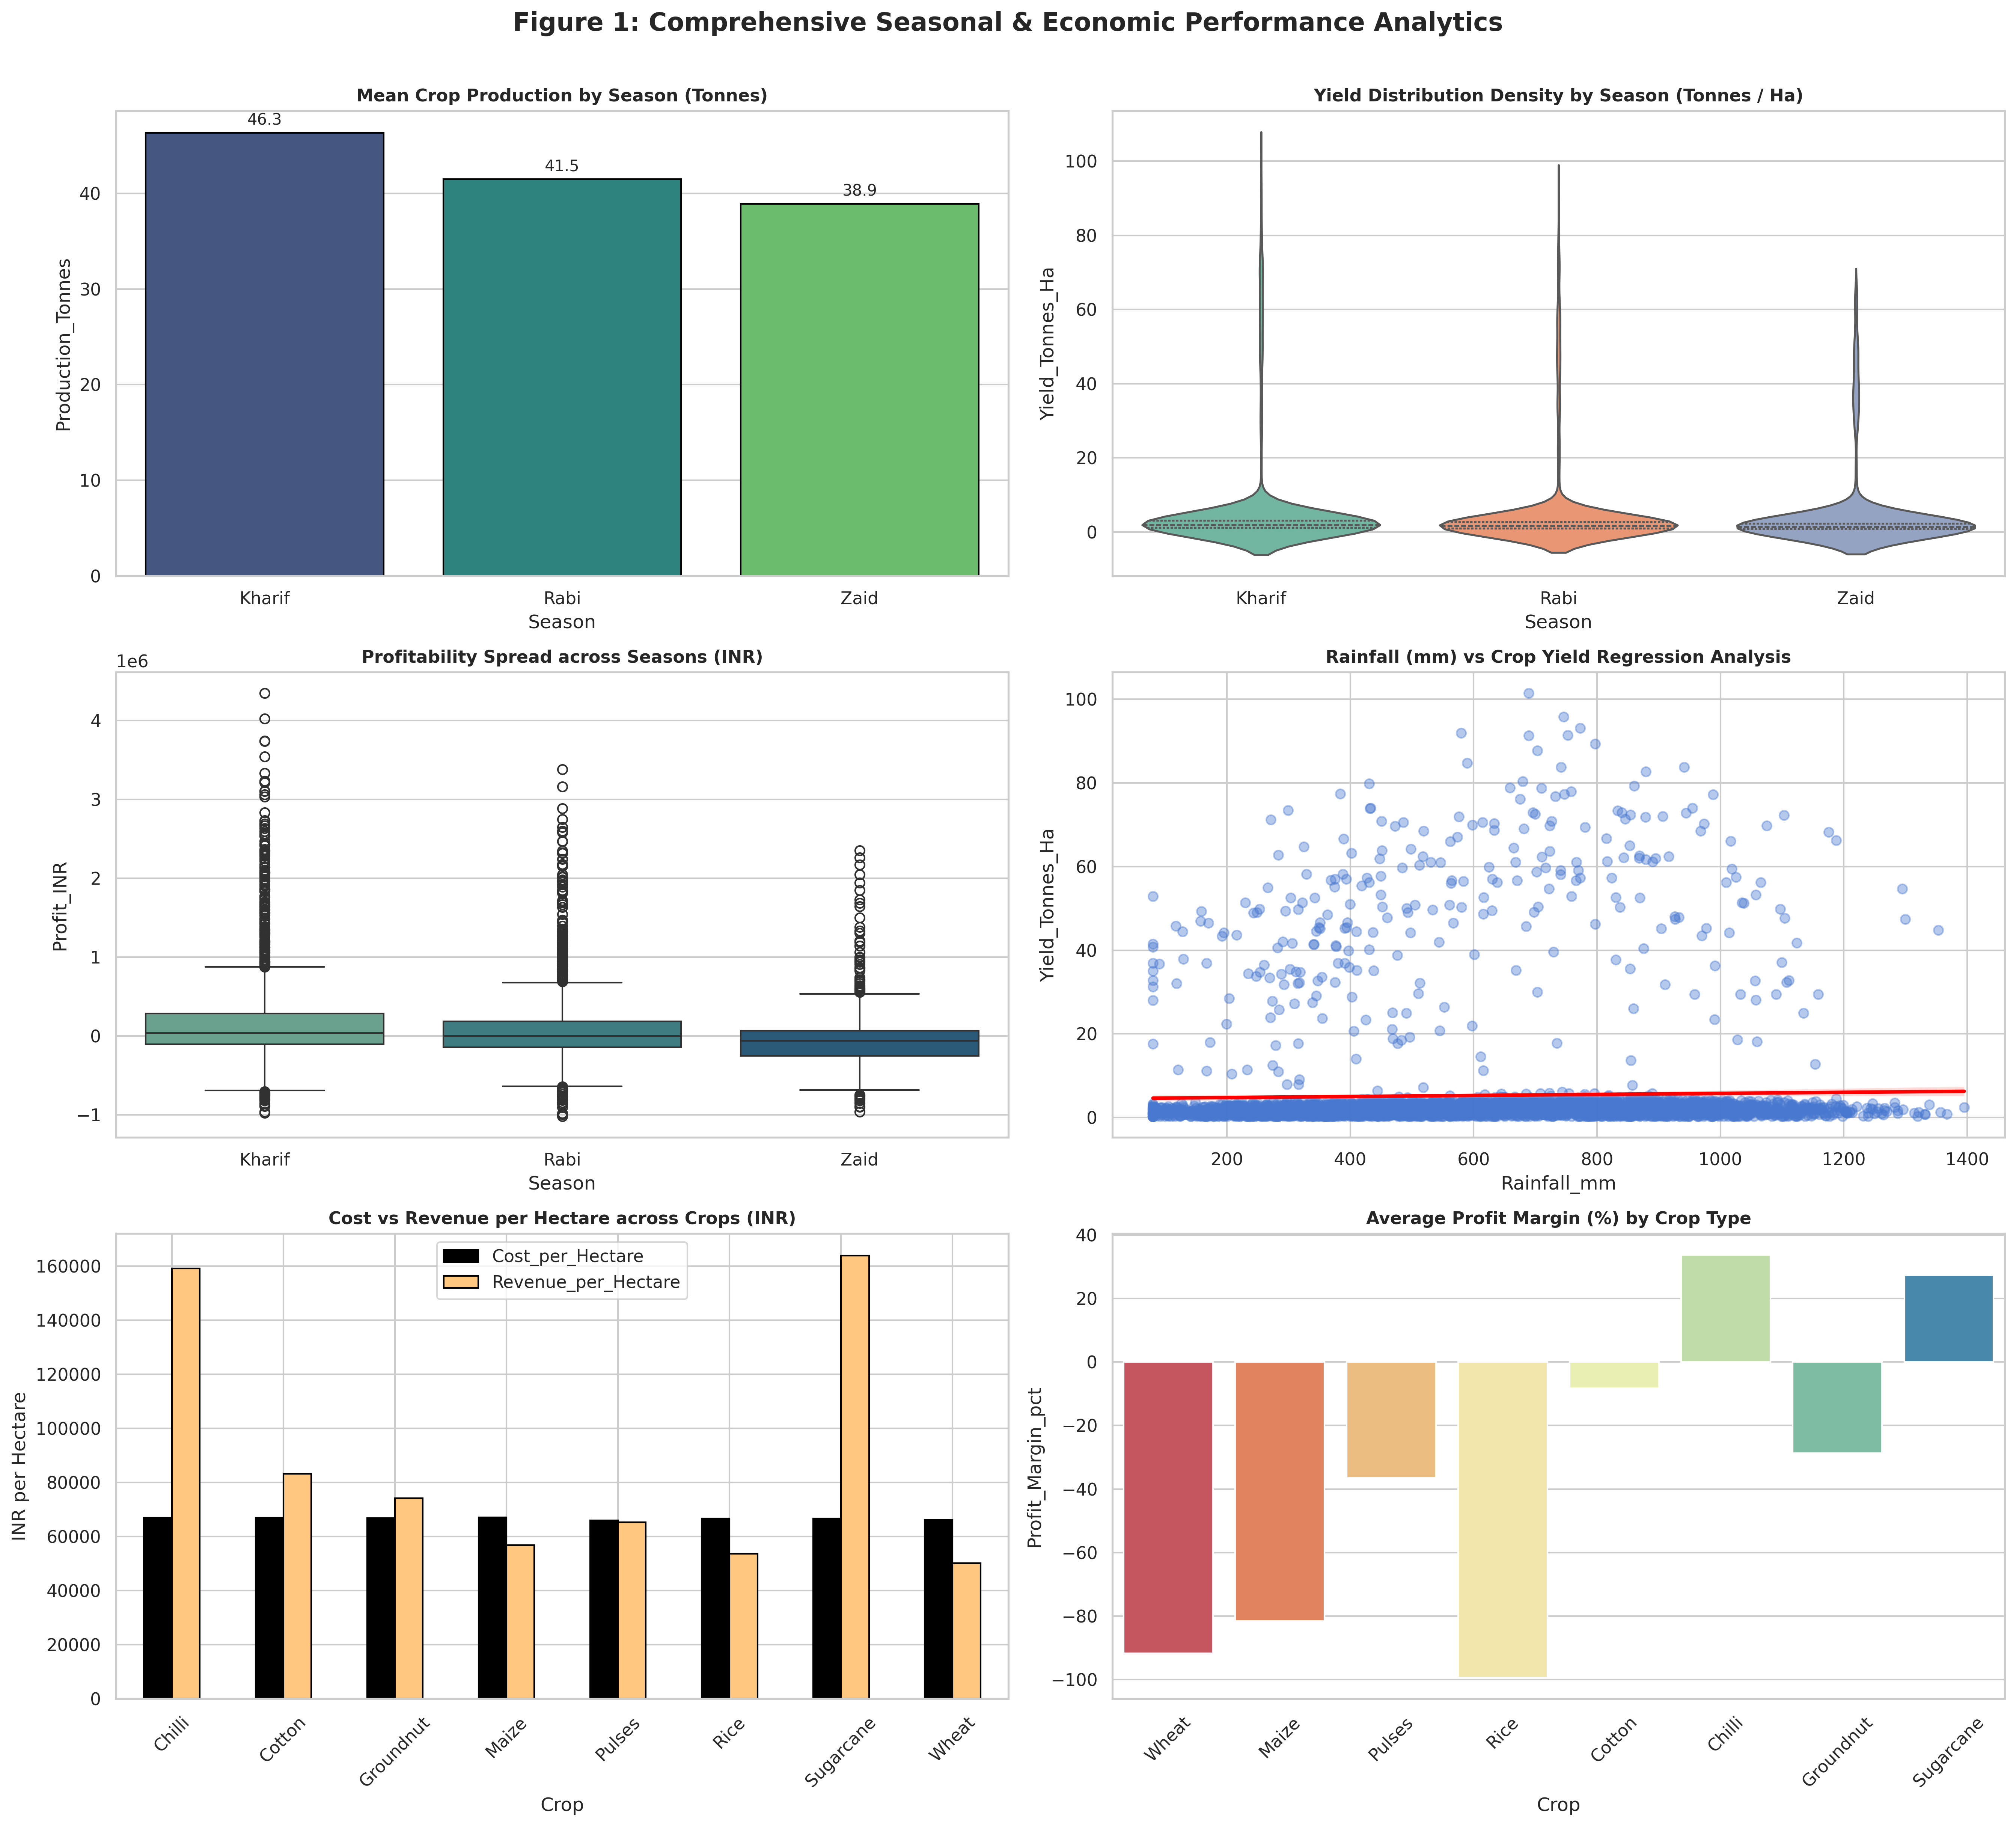

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# 1. Mean Production by Season
sns.barplot(data=df_clean, x='Season', y='Production_Tonnes', ax=axes[0, 0], ci=None, palette='viridis', edgecolor='black')
axes[0, 0].set_title('Mean Crop Production by Season (Tonnes)')
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.1f', padding=3)

# 2. Yield Variances Violin Plot
sns.violinplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', ax=axes[0, 1], palette='Set2', inner='quartile')
axes[0, 1].set_title('Yield Distribution Density by Season (Tonnes / Ha)')

# 3. Profitability Distribution Boxplot
sns.boxplot(data=df_clean, x='Season', y='Profit_INR', ax=axes[1, 0], palette='crest')
axes[1, 0].set_title('Profitability Spread across Seasons (INR)')

# 4. Rainfall vs Yield Regression Scatter
sns.regplot(data=df_clean, x='Rainfall_mm', y='Yield_Tonnes_Ha', ax=axes[1, 1], scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
axes[1, 1].set_title('Rainfall (mm) vs Crop Yield Regression Analysis')

# 5. Cost vs Revenue per Hectare by Crop
crop_perf = df_clean.groupby('Crop')[['Cost_per_Hectare', 'Revenue_per_Hectare']].mean().reset_index()
crop_perf.plot(x='Crop', kind='bar', ax=axes[2, 0], colormap='copper', edgecolor='black')
axes[2, 0].set_title('Cost vs Revenue per Hectare across Crops (INR)')
axes[2, 0].set_ylabel('INR per Hectare')
axes[2, 0].tick_params(axis='x', rotation=45)

# 6. Profitability Percentage Bar Plot by Crop
sns.barplot(data=df_clean, x='Crop', y='Profit_Margin_pct', ax=axes[2, 1], palette='Spectral', ci=None)
axes[2, 1].set_title('Average Profit Margin (%) by Crop Type')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Figure 1: Comprehensive Seasonal & Economic Performance Analytics', y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figure1_seasonal_economic_analytics.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_859/2417699692.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', ax=axes[0, 0], palette='mako', ci=None, edgecolor='black')
/tmp/ipykernel_859/2417699692.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', ax=axes[0, 0], palette='mako', ci=None, edgecolor='black')
/tmp/ipykernel_859/2417699692.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Crop', y='Soil_pH', ax=axes[1, 1], palette='Pastel1')


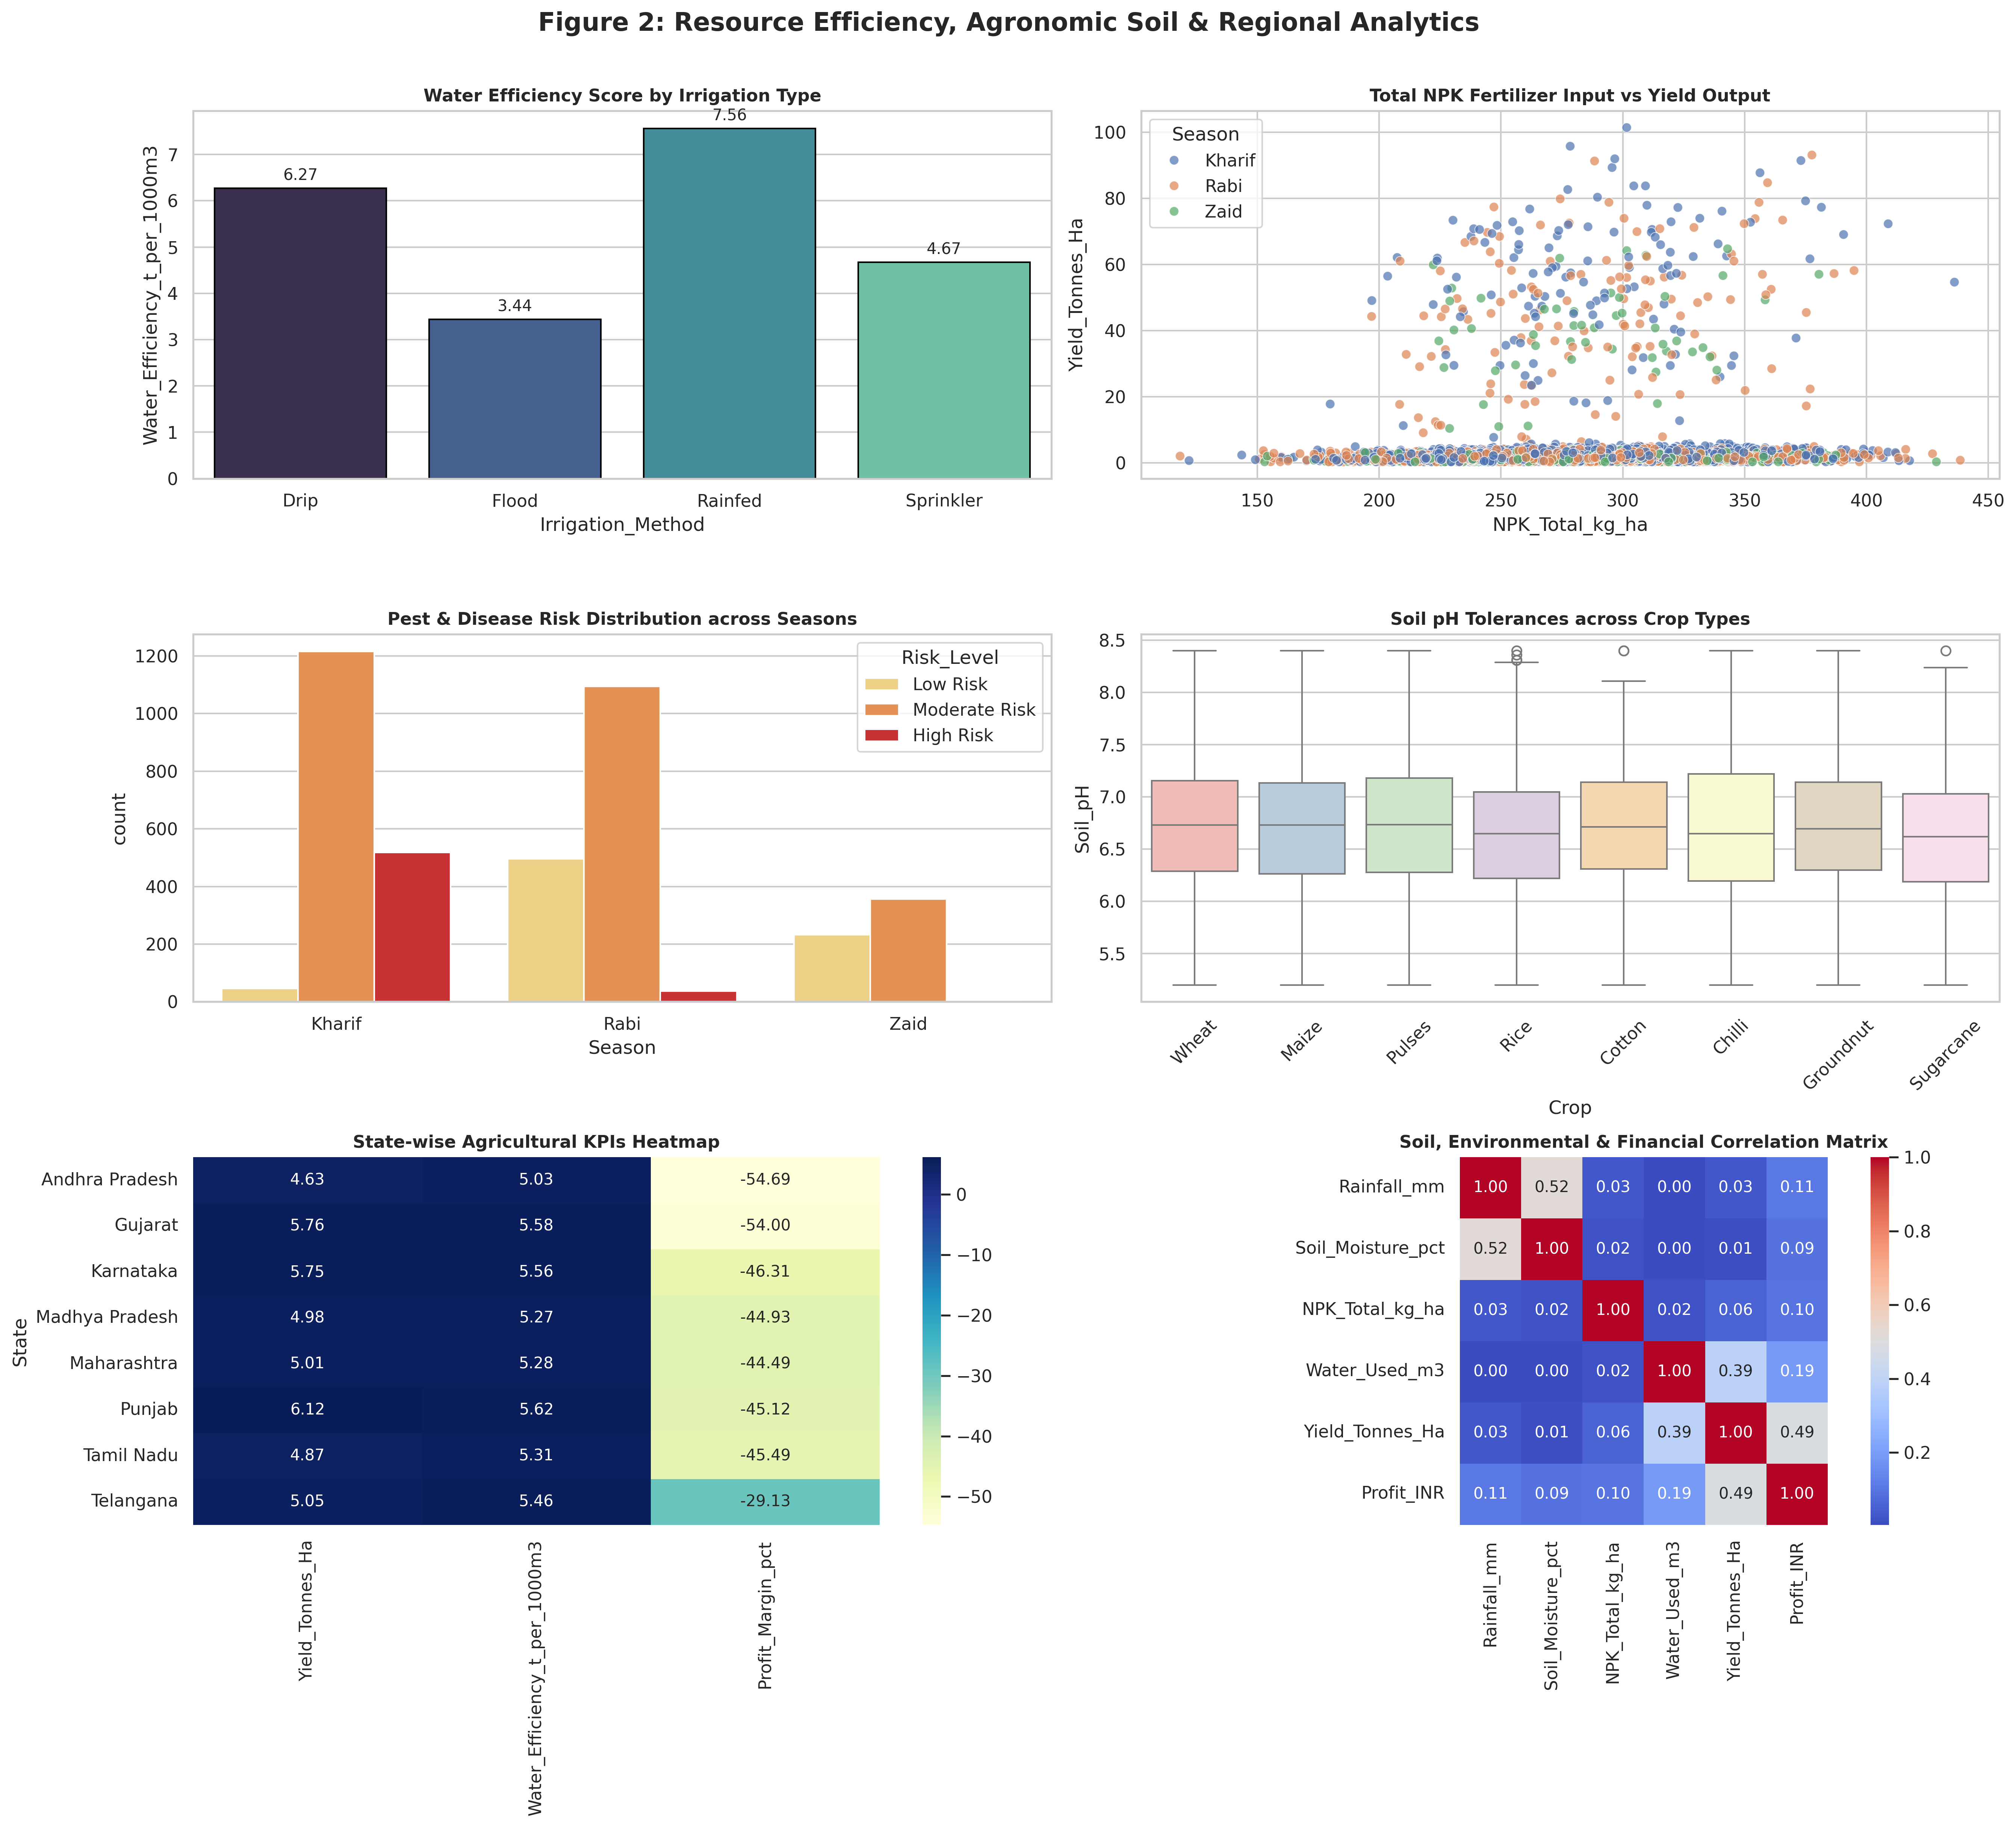

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# 1. Water Efficiency by Irrigation Method
sns.barplot(data=df_clean, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', ax=axes[0, 0], palette='mako', ci=None, edgecolor='black')
axes[0, 0].set_title('Water Efficiency Score by Irrigation Type')
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.2f', padding=3)

# 2. Total NPK Fertilizer Usage vs Yield
sns.scatterplot(data=df_clean, x='NPK_Total_kg_ha', y='Yield_Tonnes_Ha', hue='Season', ax=axes[0, 1], palette='deep', alpha=0.7)
axes[0, 1].set_title('Total NPK Fertilizer Input vs Yield Output')

# 3. Pest Risk Level Distribution by Season
sns.countplot(data=df_clean, x='Season', hue='Risk_Level', ax=axes[1, 0], palette='YlOrRd')
axes[1, 0].set_title('Pest & Disease Risk Distribution across Seasons')

# 4. Soil pH Distribution across Crops
sns.boxplot(data=df_clean, x='Crop', y='Soil_pH', ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('Soil pH Tolerances across Crop Types')
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Regional State Performance Heatmap
state_summary = df_clean.groupby('State')[['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Profit_Margin_pct']].mean()
sns.heatmap(state_summary, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[2, 0], cbar=True)
axes[2, 0].set_title('State-wise Agricultural KPIs Heatmap')

# 6. Overall Feature Correlation Matrix
corr_cols = ['Rainfall_mm', 'Soil_Moisture_pct', 'NPK_Total_kg_ha', 'Water_Used_m3', 'Yield_Tonnes_Ha', 'Profit_INR']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2, 1], square=True)
axes[2, 1].set_title('Soil, Environmental & Financial Correlation Matrix')

plt.suptitle('Figure 2: Resource Efficiency, Agronomic Soil & Regional Analytics', y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figure2_resource_soil_regional_analytics.png', dpi=300, bbox_inches='tight')
plt.show()

# 📑 Presentation Slide Deck Template

---

### **Slide 1: Title Slide**
* **Project Title**: Seasonal Agriculture Performance & Yield Optimization Analysis[cite: 1]
* **Program**: VOIS AICTE Internship Major Project (Batch 1, 2026–2027)[cite: 1]
* **Student Name**: Prathamesh Thorwat
* **AICTE Student ID**: STU6a07fdf0488dd1778908656
* **College Name**: MET BKC Institute of Engineering, Nashik
* **GitHub Repository**: https://github.com/mrsonu-boop/seasonal_agriculture_performance_analysis

---

### **Slide 2: Executive Summary & Problem Statement**
* **Context**: Agricultural yields fluctuate across Kharif, Rabi, and Zaid seasons due to irregular rainfall, soil moisture variations, and inefficient irrigation methods[cite: 1].
* **Core Problem**: Unstructured agricultural data leads to misallocated fertilizers, excessive water usage, and financial losses during dry seasons[cite: 1].
* **Objective**: Apply end-to-end data analytics to identify productivity bottlenecks and optimize farm profitability[cite: 1].

---

### **Slide 3: Technical Workflow & Stack**
* **Languages & Environments**: Python 3.x in Google Colab / Jupyter Notebook[cite: 1].
* **Data Processing**: Pandas, NumPy (Group-wise median imputation, NPK aggregation, unit standardizations)[cite: 1].
* **Visualization Suite**: Matplotlib, Seaborn (Violin plots, boxplots, multi-variable correlation heatmaps)[cite: 1].
* **Statistical Modeling**: SciPy (Skewness, IQR outlier detection, distribution analysis)[cite: 1].

---

### **Slide 4: Key Exploratory Data Analysis Insights**
1. **Seasonal Yield Disparity**: Kharif achieves highest mean production (46.31 tonnes) and profit (₹1,78,914), while Zaid experiences net losses (-₹24,804) due to high temperatures and water deficits[cite: 1].
2. **Irrigation Efficiency**: Drip irrigation delivers superior water efficiency (6.42 tonnes/1000m³) and highest net profit (₹2,19,626) compared to Flood irrigation[cite: 1].
3. **Pest & Disease Vulnerability**: Monsoon Kharif crops exhibit highest pest risk vulnerability (54.47% average risk score)[cite: 1].

---

### **Slide 5: Actionable Strategic Recommendations**
* **Scale Drip Infrastructure**: Shift flood-irrigated farms to micro-drip systems to cut water consumption and increase profit margins[cite: 1].
* **Reallocate Zaid Crops**: Transition Zaid planting from high-water crops to short-duration, heat-tolerant pulses or oilseeds[cite: 1].
* **Targeted Pest Management**: Deploy prophylactic pest control protocols ahead of Kharif monsoon cycles[cite: 1].

---

### **Slide 6: Project Repository & Code Access**
* **GitHub Repository**: https://github.com/mrsonu-boop/seasonal_agriculture_performance_analysis
* **Deliverables**: Modular `.ipynb` Jupyter Notebook, cleaned datasets, exported high-res visualization figures, and complete project documentation[cite: 1].